In [20]:
import sqlite3
import matplotlib.pyplot as plt


In [3]:
import requests
import pandas as pd

fields = "name,capital,region,subregion,population,area,currencies"
regiony = ["africa", "americas", "asia", "europe", "oceania"]
data = []

for region in regiony:
    url = f"https://restcountries.com/v3.1/region/{region}?fields={fields}"
    try:
        response = requests.get(url, timeout=30)
        kraje = response.json()
        if isinstance(kraje, list):
            data.extend(kraje)
            print(f"{region}: {len(kraje)} krajów")
    except Exception as e:
        print(f"{region}: błąd — {e}")

print(f"\nŁącznie pobrano: {len(data)} krajów")

africa: 59 krajów
americas: 56 krajów
asia: 50 krajów
europe: 53 krajów
oceania: 27 krajów

Łącznie pobrano: 245 krajów


In [9]:
def get_currency(currencies_dict):
    """Wyciąga kod pierwszej waluty z zagnieżdżonego słownika."""
    if currencies_dict:
        return list(currencies_dict.keys())[0]
    return None

df = pd.DataFrame({
    "nazwa":        [kraj.get("name", {}).get("common") for kraj in data],
    "stolica":      [kraj.get("capital", [None])[0] if kraj.get("capital") else None for kraj in data],
    "region":       [kraj.get("region") for kraj in data],
    "subregion":    [kraj.get("subregion") for kraj in data],
    "populacja":    [kraj.get("population") for kraj in data],
    "powierzchnia": [kraj.get("area") for kraj in data],
    "waluta":       [get_currency(kraj.get("currencies")) for kraj in data],
})

df.head()


,nazwa,stolica,region,subregion,populacja,powierzchnia,waluta
0,Gabon,Libreville,Africa,Middle Africa,2469296,267668.0,XAF
1,Guinea,Conakry,Africa,Western Africa,14363931,245857.0,GNF
2,Togo,Lomé,Africa,Western Africa,8095498,56785.0,XOF
3,Western Sahara,El Aaiún,Africa,Northern Africa,600904,266000.0,DZD
4,Lesotho,Maseru,Africa,Southern Africa,2116427,30355.0,LSL


In [7]:
print(f"Rozmiar: {df.shape[0]} wierszy × {df.shape[1]} kolumn")
print(f"\nTypy danych:\n{df.dtypes}")

Rozmiar: 245 wierszy × 7 kolumn

Typy danych:
nazwa               str
stolica             str
region              str
subregion           str
populacja         int64
powierzchnia    float64
waluta              str
dtype: object


In [11]:
conn = sqlite3.connect("kraje_swiata.db")

df.to_sql("kraje", conn, if_exists="replace", index=False)

print("Tabela 'kraje' zapisana w bazie 'kraje_swiata.db'")


Tabela 'kraje' zapisana w bazie 'kraje_swiata.db'


In [12]:
# Łączna populacja świata
df_populacja = pd.read_sql_query("""
    SELECT SUM(populacja) AS laczna_populacja
    FROM kraje
""", conn)

print(df_populacja)

   laczna_populacja
0        8019493760


In [13]:
# Top 10 krajów pod względem populacji
df_top10 = pd.read_sql_query("""
    SELECT nazwa, populacja
    FROM kraje
    ORDER BY populacja DESC
    LIMIT 10
""", conn)

print(df_top10)

           nazwa   populacja
0          India  1417492000
1          China  1408280000
2  United States   340110988
3      Indonesia   284438782
4       Pakistan   241499431
5        Nigeria   223800000
6         Brazil   213421037
7     Bangladesh   169828911
8         Russia   146028325
9         Mexico   130575786


In [16]:
# Liczba krajów i średnia populacja w każdym regionie
df_regiony = pd.read_sql_query("""
    SELECT
        region,
        COUNT(*) AS liczba_krajow,
        ROUND(AVG(populacja), 0) AS srednia_populacja
    FROM kraje
    GROUP BY region
    ORDER BY srednia_populacja DESC
""", conn)

print(df_regiony)

     region  liczba_krajow  srednia_populacja
0      Asia             50         94494639.0
1    Africa             59         24787532.0
2  Americas             56         18617496.0
3    Europe             53         13993546.0
4   Oceania             27          1779988.0


In [ ]:
# Kraje większe niż Polska 
df_wieksze = pd.read_sql_query("""
    SELECT nazwa, powierzchnia
    FROM kraje
    WHERE powierzchnia > 312679
    ORDER BY powierzchnia DESC
""", conn)

print(df_wieksze)

                    nazwa  powierzchnia
0                  Russia    17098246.0
1                  Canada     9984670.0
2                   China     9706961.0
3           United States     9525067.0
4                  Brazil     8515767.0
..                    ...           ...
65  Republic of the Congo      342000.0
66                Finland      338455.0
67                Vietnam      331212.0
68               Malaysia      330803.0
69            Ivory Coast      322463.0

[70 rows x 2 columns]


In [18]:
# Kraj o najwyższej gęstości zaludnienia
df_gestosc = pd.read_sql_query("""
    SELECT
        nazwa,
        populacja,
        powierzchnia,
        ROUND(populacja * 1.0 / powierzchnia, 2) AS gestosc
    FROM kraje
    WHERE powierzchnia > 0
    ORDER BY gestosc DESC
    LIMIT 1
""", conn)

print(df_gestosc)

   nazwa  populacja  powierzchnia   gestosc
0  Macau     685900          30.0  22863.33


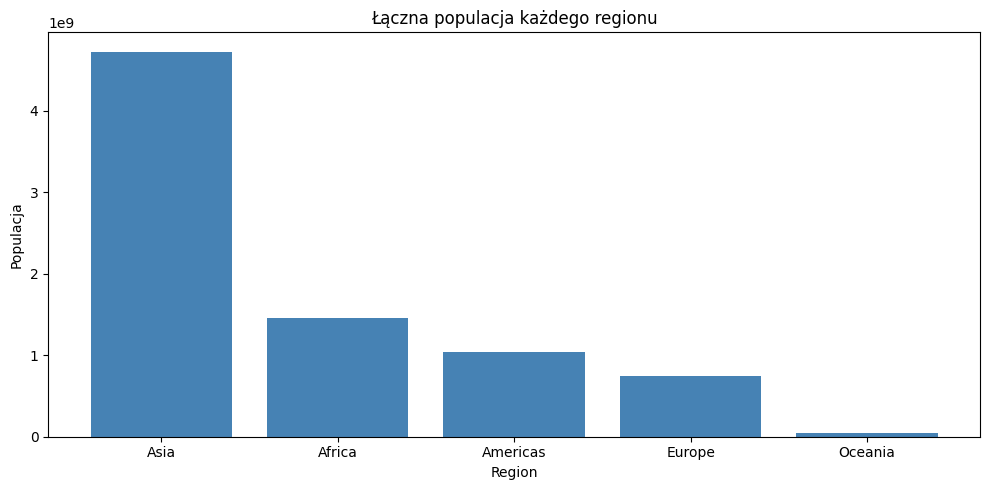

In [ ]:
df_regiony_pop = pd.read_sql_query("""
    SELECT
        region,
        SUM(populacja) AS laczna_populacja
    FROM kraje
    GROUP BY region
    ORDER BY laczna_populacja DESC
""", conn)

plt.figure(figsize=(10, 5))
plt.bar(df_regiony_pop["region"], df_regiony_pop["laczna_populacja"], color="steelblue")
plt.title("Łączna populacja każdego regionu")
plt.xlabel("Region")
plt.ylabel("Populacja")
plt.tight_layout()
plt.show()

In [22]:
conn.close()